# Potential drought impacts on agriculture [Hazard Assessment] 
Click [![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/CLIMAAX/DROUGHT/main?labpath=DROUGHT_Hazard_Assessment.ipynb) to launch this notebook on MyBinder.</br>
Click [![Drought](https://img.shields.io/badge/DROUGHT-repository-blue)](https://github.com/CLIMAAX/DROUGHT/tree/main) to go to this workflow's GitHub repository.

## Hazard assessment methodology
Introduction to Standardised Precipitation-Evapotranspiration Index (SPEI). How was computed, which data feeds the calculations, spatial resolution and which models and scenarios are available.

Post processing of SPEI to get more insights of Drought hazard. What is the threshold to define severe and extreme drought.

Maybe connect to Copernicus Atlas where it is possible to explore SPEI6 (is it the same as this one?)

## Prepare your workspace
:::{admonition} Find out about the Python libraries we will use in this notebook.
:class: hint dropdown
<!-- * [cdsapi](https://cds.climate.copernicus.eu/api-how-to) - A library to request data from the datasets listed in the CDS catalogue. -->
* [numpy](https://numpy.org/doc/stable/) - A powerful library for numerical computations in Python, widely used for array operations and mathematical functions.
* [xarray](https://docs.xarray.dev/en/stable/) - Introduces labels in the form of dimensions, coordinates and attributes on top of raw NumPy-like arrays for a more intuitive experience.
* [rioxarray](https://corteva.github.io/rioxarray/stable/) - An extension of the xarray library that simplifies working with geospatial raster data.
* [scipy](https://docs.scipy.org/doc/scipy/) - Provides algorithms for optimization, statistics and many other classes of problems.
* [matplotlib](https://matplotlib.org/stable/) -  A versatile plotting library in Python, commonly used for creating static, animated, and interactive visualizations.
* [cartopy](https://scitools.org.uk/cartopy/docs/latest/) - A package designed for geospatial data processing in order to produce maps and other geospatial data analyses.
* [contextily](https://contextily.readthedocs.io/en/latest/) - To retrieve matplotlib compatible tile maps from the internet.

### Load libraries

In [1]:
# Libraries to download data and manage files
import os
import zipfile
import glob

# Libraries for numerical computations, array manipulation and statistics.
import numpy as np
import xarray as xr

# Libraries to handle geospatial data
import rioxarray as rio
import pyproj

# Libraries to compute climate indicators and indices
import xclim.indices as xci

# Libraries to plot maps, charts and tables
import matplotlib.pyplot as plt
from matplotlib.colors import from_levels_and_colors
from matplotlib.colors import LinearSegmentedColormap
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
import plotly.express as px
from pyproj import Transformer
import contextily as ctx
import calendar

# Choosing the matplotlib backend
%matplotlib inline

### Setting your directory
The next cell will create the *drought_workflow* directory in the same directory where the notebook is saved.

In [2]:
# Define the directory for the heavy workflow preprocess
workflow_dir = 'drought_workflow'

# Define directories for data and results within the previously defined workflow directory
data_dir = os.path.join(workflow_dir, 'data')
results_dir = os.path.join(workflow_dir, 'results')

# Create the workflow directory if it doesn't exists, along with subdirectories for data and results.
os.makedirs(workflow_dir, exist_ok = True)
os.makedirs(data_dir, exist_ok = True)
os.makedirs(results_dir, exist_ok = True)

### Select your area of study

Before downloading the data, let us define the coordinates of the area of interest. Based on these coordinates we will be able to clip the datasets for further processing, and eventually display hazard maps for the selected area.

To easily define an area in terms of geographical coordinates, you can go to the [Bounding Box Tool](https://boundingbox.klokantech.com) to select a region and get the coordinates. Make sure to select ‘CSV’ in the lower left corner and copy the values in the brackets below.

In [3]:
bbox = [0,40,4,44]; areaname = 'Catalonia'

---

## Step 1: Download SPEI dataset

In [4]:
# Code to download SPEI dataset from Cloud (waiting for implementation)
# Or maybe use the dataset availble from CDS directly with cdsapi (right now only SPI6, but 32 members).
# Right now, it is necessary to have the SPEI files in the directory defined as data_dir in order to work.

Extract the downloaded files to your data directory.

In [5]:
#with zipfile.ZipFile(zip_path, 'r') as zObject:
#    zObject.extractall(path=data_dir)

---

## Step 2: Explore the SPEI dataset
The SPEI files downloaded have a filename structure that describes the exact dataset contained. The general structure is the following:

<p style="text-align: center;">SPEI[month aggregation]_[gcm]_[ssp]_RF_[reference period]_[years available]</p>

Load one of the files and explore the content and structure of the dataset. Notice the dimensions, coordinates,  data variables, indexes and attributes.

In [6]:
# Define the path to a specific file
scenario = 'ssp370'
spei_dur = 6
gcm = 'mri-esm2-0'

filename_spei = f'drought_workflow/data/SPEI{spei_dur}_{gcm}_{scenario}_RF_1951-2000_2015-2100_Catalonia.nc'
# Open the netCDF file as a dataset using xarray
ds_spei = xr.open_dataset(filename_spei, decode_coords = 'all')

print(os.path.basename(filename_spei))
# Display said dataset
ds_spei

SPEI6_mri-esm2-0_ssp370_RF_1951-2000_2015-2100_Catalonia.nc


<xarray.Dataset> Size: 273kB
Dimensions:      (lon: 8, lat: 8, time: 1032)
Coordinates:
  * lon          (lon) float64 64B 0.25 0.75 1.25 1.75 2.25 2.75 3.25 3.75
  * lat          (lat) float64 64B 40.25 40.75 41.25 41.75 ... 42.75 43.25 43.75
  * time         (time) datetime64[ns] 8kB 2015-01-16T12:00:00 ... 2100-12-16...
    spatial_ref  int64 8B ...
Data variables:
    SPEI         (time, lat, lon) float32 264kB ...

Let's plot this dataset for a specific months and years. Notice that latitude and longitude are defined following the usual Coordinate Reference System (CRS) known as WGS84, although the latitude coordinate decreases.

In [7]:
# Define SPEI dataset's CRS.
crs = ccrs.Projection('EPSG:4326')

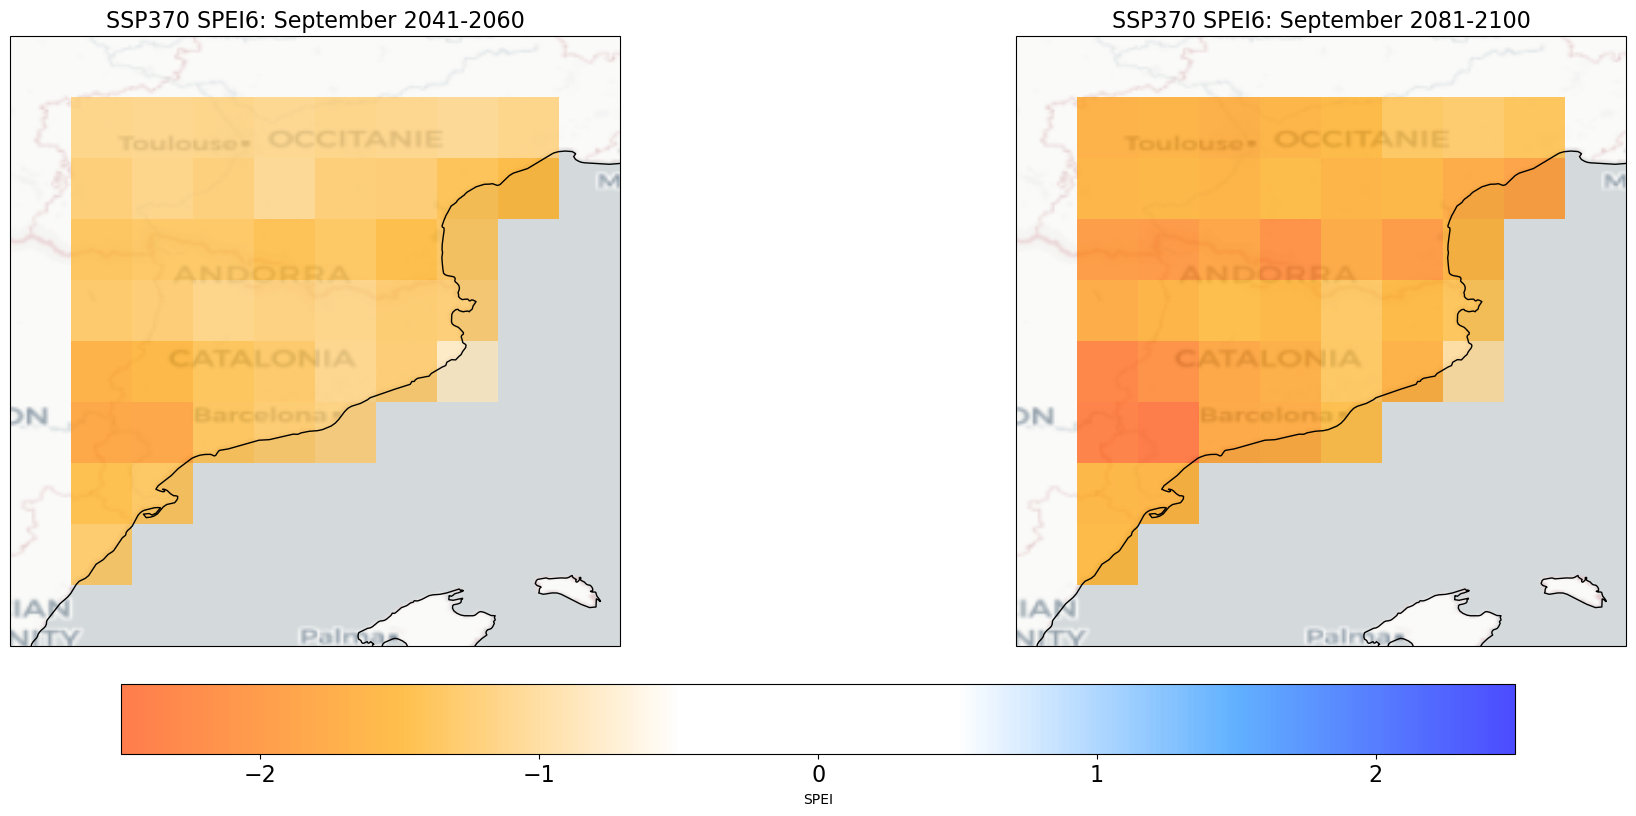

In [8]:
# Define months and year ranges
#MONTHS = [6, 12]
MONTHS = [9]
YEAR_RANGES = [(2041, 2060), (2081, 2100)]
vmin, vmax = -2.5, 2.5

colors = [
    (0.0, "orangered"),
    (0.2, "orange"),
    (0.4, "white"),
    (0.6, "white"),
    (0.8, "dodgerblue"),
    (1.0, "blue")
]
red_white_blue = LinearSegmentedColormap.from_list("custom_cmap", colors)

# Define the bounding box
fig, axes = plt.subplots(len(MONTHS), len(YEAR_RANGES), 
                         figsize=(10*len(YEAR_RANGES), 8*len(MONTHS)), 
                         layout='constrained', sharey=True, 
                         subplot_kw={'projection': ccrs.PlateCarree()})
                                                
for j, month_j in enumerate(MONTHS):
    for i, (start_year, end_year) in enumerate(YEAR_RANGES):
        # Select only the desired months and years
        ds_mon_avg = ds_spei.SPEI.sel(
            time=slice(f"{start_year}-01-01", f"{end_year}-12-31")
        ).where(ds_spei.time.dt.month.isin(MONTHS), drop=True).mean(dim='time')

        ax = axes[j, i] if len(MONTHS) > 1 else axes[i]  # Adjust indexing

        # Set the extent to the bounding box
        ax.set_extent([bbox[0]-0.5, bbox[2]+0.5, bbox[1]-0.5, bbox[3]+0.5], crs=ccrs.PlateCarree())

        # Plot the average for the selected month
        pcm = ds_mon_avg.plot(ax=ax, cmap=red_white_blue, alpha=0.7, vmin=vmin, vmax=vmax, add_colorbar=False)

        ax.set_title(f'{scenario.upper()} SPEI{spei_dur}: {calendar.month_name[month_j]} {start_year}-{end_year}', fontsize=16)
        
        # Add coastlines and other cartopy features
        ax.add_feature(cfeature.COASTLINE)
        #ax.add_feature(cfeature.BORDERS, linestyle=':')
        ctx.add_basemap(ax=ax, crs="EPSG:4326", source=ctx.providers.CartoDB.Positron, 
                        attribution=False, zoom=6)

fig.colorbar(pcm, ax=axes[:, :] if len(MONTHS) > 1 else axes[:], location='bottom', shrink=0.7, label='SPEI').ax.tick_params(labelsize=16)

plt.show()

The extent of this dataset is global, therefore the number of points along latitude and longitude axes is very large. This dataset needs to be clipped to our area of interest. It can also be reprojected to a specific CRS in order to match local data. 

:::{note}
The SPEI dataset has a somewhat coarse spatial resolution. Please modify your defined bounding box if the new local dataset has no longitude or latitude points.
:::

## Step 3: Clip dataset to local area.
In order to asses how drought is going to change, we will need to load and clip the datasets for both historical (1951-2014) and future simulations (2015-2100).

In [9]:
# Select which dataset
T_AGG = 6 # Temporal aggregation of SPEI
GCM = 'mri-esm2-0' # Global climate model
SSP = 'ssp370' # Shares-socioeconomic pathway for future simulations

In [10]:
# Load both historical and future period
#for run in ['historical', SSP]:
#    # Read the specific file 
#    file_i = glob.glob(os.path.join('data',f'SPEI{T_AGG}_{GCM}_{run}_*[0-9].nc'))[0]#

    #file_i = f'data/SPEI{T_AGG}_{GCM}_{run}_*[0-9].nc'
    #file_i = filename_spei_example
#    ds_i = xr.open_dataset(file_i, decode_coords = 'all')
    # Invert latitude coordinate.
#    ds_i = ds_i.isel(lat=slice(None, None, -1))
    # Write CRS and clip to box
#    ds_i_clip = ds_i.SPEI.rio.write_crs(crs).rio.clip_box(*bbox)
    # Name of the clipped file
#    file_out_i = os.path.basename(file_i).replace('.nc', f'_{areaname}.nc')
#    print(file_out_i)
#    # Save netCDF in restults directory
#    ds_i_clip.to_netcdf(os.path.join(data_dir, file_out_i))

## Step 4: Calculate some drought characterisitcs.
Following [Chiang et al](https://doi.org/10.1038/s41467-021-22314-w), we will compute drought frequency, maximum duration of drougth events and maximum intensity of drought events.

In this example, two 30-year windows are selected: a historical one (1985-2014) and a future horizon (2041-2070).

In [11]:
# Define thresholds for drought definition
THRESHOLDS = { 
    'severe' : -1.5,
    'extreme' : -2
}

# Define year windows for each period.
YEAR_WINDOWS = {
    'historical' : ['1985', '2014'],
    scenario : ['2041', '2070']
}

In [12]:
for run, window in YEAR_WINDOWS.items():
    file_i = glob.glob(os.path.join(data_dir, f'SPEI{spei_dur}_{gcm}_{run}_*_{areaname}.nc'))[0]
    ds_i = xr.open_dataset(file_i, decode_coords='all')
    ds_i = ds_i.where(ds_i['time'].dt.month == MONTHS[0], drop=True)
    da_i = ds_i.sel(time=slice(window[0], window[1])).SPEI

    # Positions where SPEI dataset is NAN
    da_nan = da_i[0, :, :].isnull().data
    del ds_i

    for thr_class, thr_val in THRESHOLDS.items():
        # Drought event frequency
        drought_freq = xr.where(
            (da_i < thr_val) & (da_i.shift(time=1, fill_value=0) > thr_val),
            1, np.nan
        ).sum(dim='time')
        drought_freq.values[da_nan] = np.nan
        drought_freq.attrs = {
            'units': '-',
            'long_name': 'Number of non-consecutive drought events'
        }

        # Maximum duration (in months) of drought event
        drought_max_duration = xci.run_length.longest_run(da_i < thr_val)
        drought_max_duration.values[da_nan] = np.nan
        drought_max_duration.attrs = {
            'units': 'years',
            'long_name': 'Maximum duration of drought event'
        }

        # Drought conditions (Boolean mask)
        drought_mask = da_i < thr_val
        
        # Calculate cumulative SPEI values for drought events
        # Here we use SPEI values where drought conditions are true
        cumulative_intensity = da_i.where(drought_mask).cumsum(dim="time")
        
        # Cumulative intensity of longest drought
        drought_max_intensity = cumulative_intensity.min(dim="time")

        drought_max_intensity.values[da_nan] = np.nan
        
        drought_max_intensity.attrs = {
            'units': '-',
            'long_name': f'Maximum cumulative intensity of {thr_class} drought event'
        }

        # Write Dataset with the 3 new statistics of drought
        drought_statistics = xr.Dataset(
            data_vars={
                'frequency': drought_freq,
                'max_duration': drought_max_duration,
                'max_intensity': drought_max_intensity
            }
        )
        file_name = f'{thr_class}_drought_{gcm}_{run}_{window[0]}_{window[1]}_{areaname}.nc'
        file_path = os.path.join(results_dir, file_name)
        os.path.exists(file_path) and os.remove(file_path)
        drought_statistics.to_netcdf(file_path, mode='w')

## Step 5: Visualize drought features.
Now we can plot the change of drought features between the two 30-year periods.

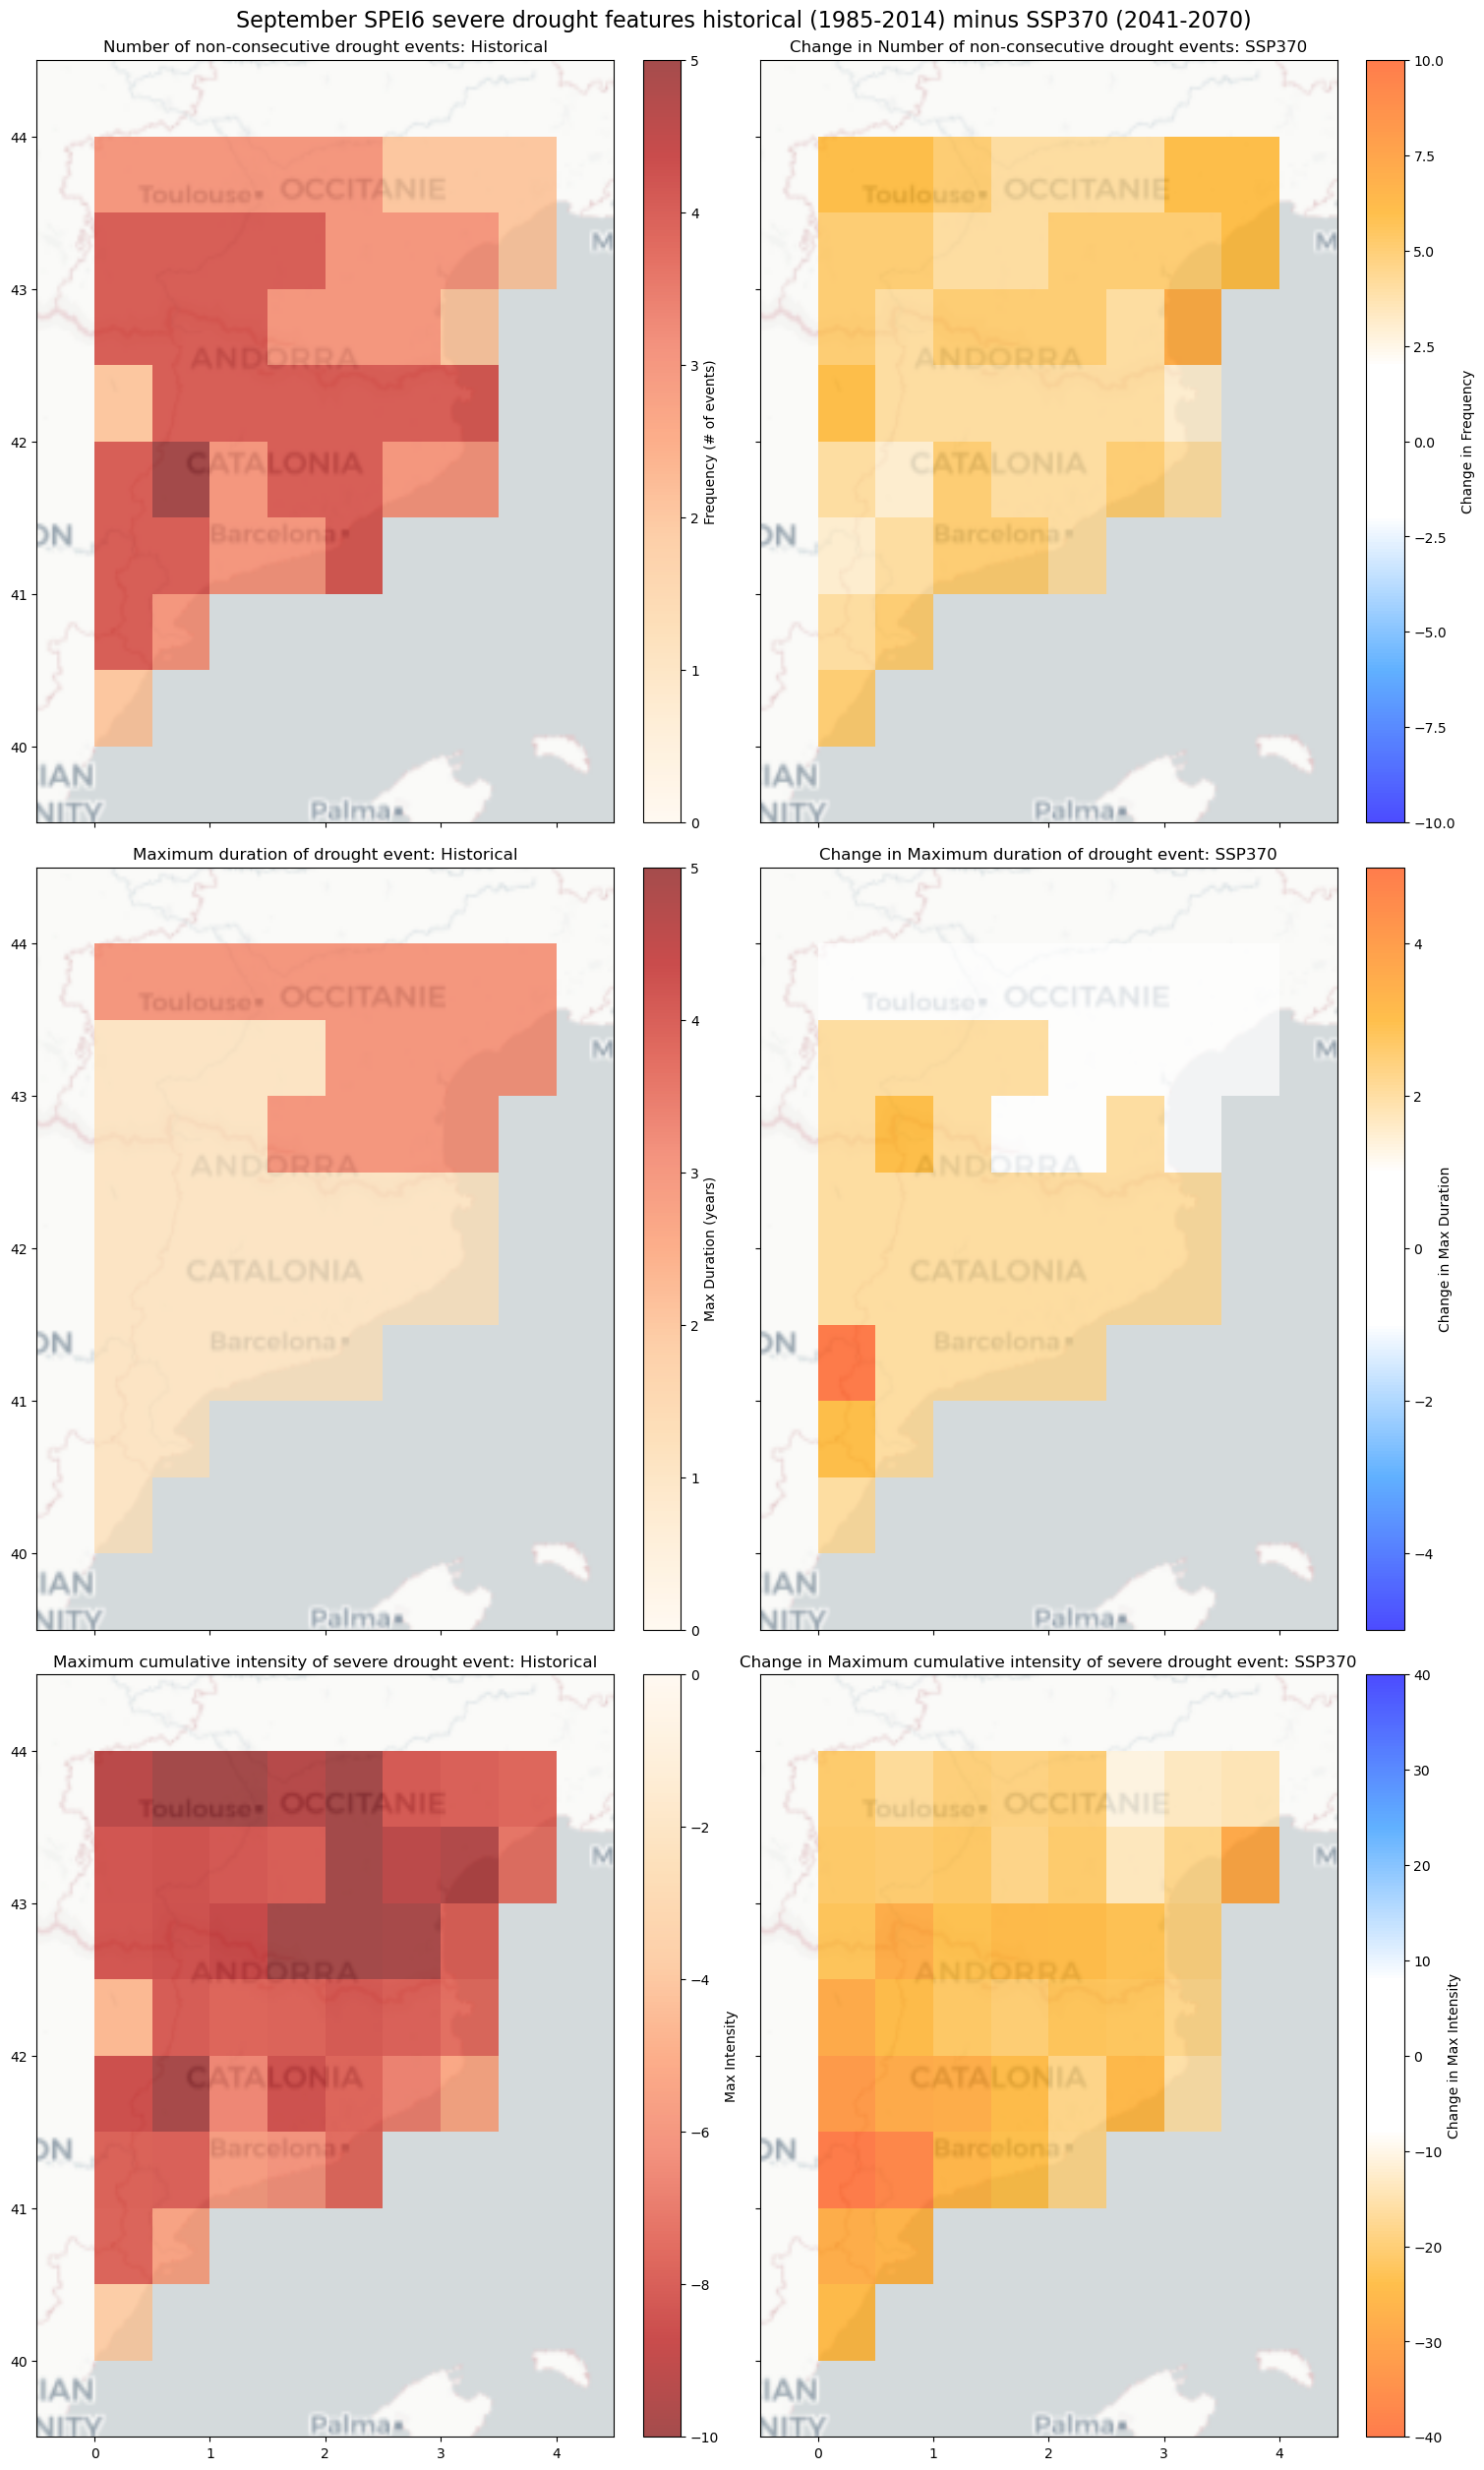

In [13]:
# Select drought threshold
thr_class = 'severe'

# Create a 3x2 figure for the plots
fig, axes = plt.subplots(3, 2, figsize=(15, 25), layout='constrained', sharey=True, sharex=True)

# Load the dataset paths
paths = [glob.glob(os.path.join(results_dir, f'{thr_class}_drought_{gcm}_{run}_*_{areaname}.nc'))[0] for run in YEAR_WINDOWS.keys()]
ds = [xr.open_dataset(path_i, decode_coords='all') for path_i in paths]
ds_diff = ds[1] - ds[0]  # Difference dataset

# Define custom settings for absolute maps (ds[0] and ds[1])
absolute_settings = {
    'frequency': {'vmin': 0, 'vmax': 5, 'cmap': 'OrRd', 'label': 'Frequency (# of events)'},
    'max_duration': {'vmin': 0, 'vmax': 5, 'cmap': 'OrRd', 'label': 'Max Duration (years)'},
    'max_intensity': {'vmin': -10, 'vmax': 0, 'cmap': 'OrRd_r', 'label': 'Max Intensity'},
}

# Define custom settings for difference maps (ds_diff)
difference_settings = {
    'frequency': {'vmin': -10, 'vmax': 10, 'cmap': red_white_blue.reversed(), 'label': 'Change in Frequency'},
    'max_duration': {'vmin': -5, 'vmax': 5, 'cmap': red_white_blue.reversed(), 'label': 'Change in Max Duration'},
    'max_intensity': {'vmin': -40, 'vmax': 40, 'cmap': red_white_blue, 'label': 'Change in Max Intensity'},
}

# Loop through the statistics (data variables) in ds[0]
for j, stat in enumerate(ds[0].data_vars.variables):
    # Left column: Absolute values from ds[0] (Historical)
    abs_settings = absolute_settings[stat]
    im0 = ds[0][stat].plot(ax=axes[j, 0],
                           cmap=abs_settings['cmap'],
                           add_colorbar=False,
                           vmin=abs_settings['vmin'],
                           vmax=abs_settings['vmax'],
                           alpha=0.7,
                           xlim=(bbox[0] - 1, bbox[2] + 1),
                           ylim=(bbox[1] - 1, bbox[3] + 1))
    cbar0 = plt.colorbar(im0, ax=axes[j, 0])
    cbar0.set_label(f"{abs_settings['label']}")
    ctx.add_basemap(ax=axes[j, 0], crs='EPSG:4326', source=ctx.providers.CartoDB.Positron, zoom=6, attribution=False)
    axes[j, 0].set_title(f"{ds[0][stat].attrs['long_name']}: Historical")
    axes[j, 0].set_xlabel("")
    axes[j, 0].set_ylabel("")

    # Right column: Difference map from ds_diff
    diff_settings = difference_settings[stat]
    diff_im = ds_diff[stat].plot(ax=axes[j, 1],
                                 cmap=diff_settings['cmap'],
                                 add_colorbar=False,
                                 vmin=diff_settings['vmin'],
                                 vmax=diff_settings['vmax'],
                                 alpha=0.7,
                                 xlim=(bbox[0] - 0.5, bbox[2] + 0.5),
                                 ylim=(bbox[1] - 0.5, bbox[3] + 0.5))
    diff_cbar = plt.colorbar(diff_im, ax=axes[j, 1])
    diff_cbar.set_label(f"{diff_settings['label']}")
    ctx.add_basemap(ax=axes[j, 1], crs='EPSG:4326', source=ctx.providers.CartoDB.Positron, zoom=6, attribution=False)
    axes[j, 1].set_title(f"Change in {ds[0][stat].attrs['long_name']}: {run.upper()}")
    axes[j, 1].set_xlabel("")
    axes[j, 1].set_ylabel("")

# Add an overarching title
fig.suptitle(f'{calendar.month_name[month_j]} SPEI{spei_dur} {thr_class} drought features historical ({YEAR_WINDOWS['historical'][0]}-{YEAR_WINDOWS['historical'][1]}) minus {run.upper()} ({YEAR_WINDOWS[scenario][0]}-{YEAR_WINDOWS[scenario][1]})', fontsize= 16);
plt.show()

## Conclusions

---
## Authors


--- 

## References

